In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Molecules_Toxicity_Classification.csv to Molecules_Toxicity_Classification.csv


In [ ]:
import pandas as pd
df = pd.read_csv('Molecules_Toxicity_Classification.csv')

In [ ]:
# Display the first few rows to get an idea of our data
print("\nFirst 5 rows of your data:")
print(df.head())

# Get some basic information about the data
print("\nInformation about the data:")
print(df.info())

# Get descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
print(df.describe())


First 5 rows of your data:
   Unnamed: 0  MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  \
0           0  0.0908         0  0.0075  0.0173                0        0.0   
1           1  0.0213         0  0.1144 -0.0410                0        0.0   
2           2  0.0018         0 -0.0156 -0.0765                2        0.0   
3           3 -0.0251         0 -0.0064 -0.0894                3        0.0   
4           4 -0.0028         2 -0.0164 -0.0912                2        0.0   

   MATS3e  MATS3c  minHBint2  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0 -0.0436  0.0409     0.0000  ...   0.0000   0.0000      0.1780      1.5488   
1  0.1231 -0.0316     0.0000  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1138 -0.1791     0.0000  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.0747 -0.1151     0.0000  ...   7.7896  24.7336      0.1702      1.4654   
4 -0.0356 -0.0159     6.0139  ...  15.6022   6.2113      0.1755      1.4774   

   ETA_EtaP_B  nT5Ring


'Unnamed: 0' column dropped.

Distribution of the 'Class' variable:
Class
NonToxic    108
Toxic        51
Name: count, dtype: int64


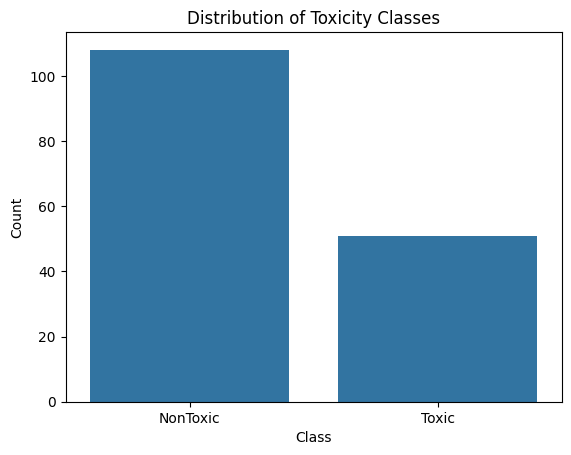

In [ ]:
# Drop the 'Unnamed: 0' column
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("\n'Unnamed: 0' column dropped.")
else:
    print("\n'Unnamed: 0' column not found.")

# Check the distribution of the target variable 'Class'
print("\nDistribution of the 'Class' variable:")
print(df['Class'].value_counts())

# Visualize the class distribution
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Class', data=df)
plt.title('Distribution of Toxicity Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
# Separate features (X) and target (y)
X = df.drop(columns=['Class'])
y = df['Class']

print("\nShape of feature matrix (X):", X.shape)
print("Shape of target vector (y):", y.shape)
print("\nFirst 5 rows of features (X):")
print(X.head())
print("\nFirst 5 values of target (y):")
print(y.head())


Shape of feature matrix (X): (159, 1203)
Shape of target vector (y): (159,)

First 5 rows of features (X):
   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4 -0.0028         2 -0.0164 -0.0912                2        0.0 -0.0356   

   MATS3c  minHBint2  MATS3m  ...   WTPT-3   WTPT-4   WTPT-5  ETA_EtaP_L  \
0  0.0409     0.0000  0.1368  ...   0.0000   0.0000   0.0000      0.1780   
1 -0.0316     0.0000  0.1318  ...  28.2185   8.8660  19.3525      0.1739   
2 -0.1791     0.0000  0.0615  ...  33.1064   5.2267  27.8796      0.1688   
3 -0.1151     0.0000  0.0361  ...  32.5232   7.7896  24.7336      0.1702   
4 -0.0159     6.0139  0.0922  ...  21.8135  15.6022   6.2113 

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the target variable
y_encoded = label_encoder.fit_transform(y)

# Print the mapping of classes to encoded values
print("\nClass mapping:")
for original_class, encoded_value in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{original_class}: {encoded_value}")

# Print the first 5 encoded target values
print("\nFirst 5 encoded target values (y_encoded):")
print(y_encoded[:5])


Class mapping:
NonToxic: 0
Toxic: 1

First 5 encoded target values (y_encoded):
[0 0 0 0 0]


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
# Split the data into training and testing sets
# stratify=y_encoded ensures that the class proportions are maintained
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# Check the class distribution in the training and testing sets
print("\nClass distribution in y_train:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
print(dict(zip(label_encoder.inverse_transform(unique_train), counts_train)))

print("\nClass distribution in y_test:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
print(dict(zip(label_encoder.inverse_transform(unique_test), counts_test)))


Shape of X_train: (127, 1203)
Shape of X_test: (32, 1203)
Shape of y_train: (127,)
Shape of y_test: (32,)

Class distribution in y_train:
{'NonToxic': np.int64(86), 'Toxic': np.int64(41)}

Class distribution in y_test:
{'NonToxic': np.int64(22), 'Toxic': np.int64(10)}


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFirst 5 rows of scaled training data (X_train_scaled):")
print(X_train_scaled[:5, :5])  # Print the first 5 rows and 5 columns

print("\nFirst 5 rows of scaled testing data (X_test_scaled):")
print(X_test_scaled[:5, :5])   # Print the first 5 rows and 5 columns


First 5 rows of scaled training data (X_train_scaled):
[[-1.56759585  0.92668627  0.42170262 -1.62952335  0.        ]
 [-0.43255962 -0.42606265 -0.0081154  -0.34323421 -0.8592858 ]
 [-0.48539164 -0.42606265 -1.54577421  0.26041249  0.8592858 ]
 [-0.69842396 -0.42606265  0.85152064 -0.51613055 -0.8592858 ]
 [ 0.20312884 -0.42606265  0.41867573 -0.0421561  -0.8592858 ]]

First 5 rows of scaled testing data (X_test_scaled):
[[-0.93190739 -0.42606265  0.35965143 -1.54307518 -0.8592858 ]
 [-0.4581235   2.2794352  -0.49847116 -0.08985164  0.8592858 ]
 [ 0.38548451 -0.42606265 -0.33804613  0.5927908  -0.8592858 ]
 [-2.63105321  2.2794352  -0.32291169 -2.59833904  0.        ]
 [-0.65240898 -0.42606265 -0.26237394 -2.13032654  0.8592858 ]]



Cross-validation accuracy scores: [0.34615385 0.5        0.64       0.56       0.36      ]
Mean cross-validation accuracy: 0.4812 (+/- 0.1138)

--- Test Set Evaluation ---
Test set accuracy: 0.5000

Classification Report:
              precision    recall  f1-score   support

    NonToxic       0.69      0.50      0.58        22
       Toxic       0.31      0.50      0.38        10

    accuracy                           0.50        32
   macro avg       0.50      0.50      0.48        32
weighted avg       0.57      0.50      0.52        32



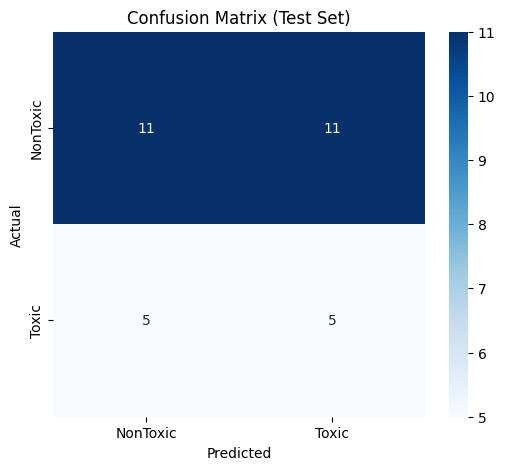

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize Logistic Regression model
logreg = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')

# Define cross-validation strategy (StratifiedKFold for imbalanced data)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation on the training data
cv_scores = cross_val_score(logreg, X_train_scaled, y_train, cv=cv, scoring='accuracy')
print(f"\nCross-validation accuracy scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Train the Logistic Regression model on the entire scaled training data
logreg.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred = logreg.predict(X_test_scaled)

# Evaluate the model on the test data
print("\n--- Test Set Evaluation ---")
print(f"Test set accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set)')
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [  64  240  352  603  620  765 1034 1125 1164] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectKBest was fitted with feature names
  warnings.warn(



--- Feature Selection with k=50 ---
Shape of X_train_selected (k=50): (127, 50)
Shape of X_test_selected (k=50): (32, 50)
Number of selected features (k=50): 50
First 20 selected feature names (k=50): ['MATS3p', 'minHBint2', 'minHBint4', 'MATS3i', 'VR3_Dt', 'VR2_Dt', 'nT6Ring', 'AATSC3i', 'AATSC3p', 'MATS1s', 'khs.ssS', 'minssNH', 'nBase', 'SpDiam_Dzi', 'ATSC3p', 'maxssNH', 'minssS', 'SHaaCH', 'GATS3p', 'GATS3i']

Cross-validation accuracy scores (k=50): [0.53846154 0.53846154 0.6        0.72       0.4       ]
Mean cross-validation accuracy (k=50): 0.5594 (+/- 0.1037)

--- Test Set Evaluation (k=50 features) ---
Test set accuracy (k=50): 0.3750

Classification Report (k=50):
              precision    recall  f1-score   support

    NonToxic       0.56      0.41      0.47        22
       Toxic       0.19      0.30      0.23        10

    accuracy                           0.38        32
   macro avg       0.38      0.35      0.35        32
weighted avg       0.45      0.38      0.40

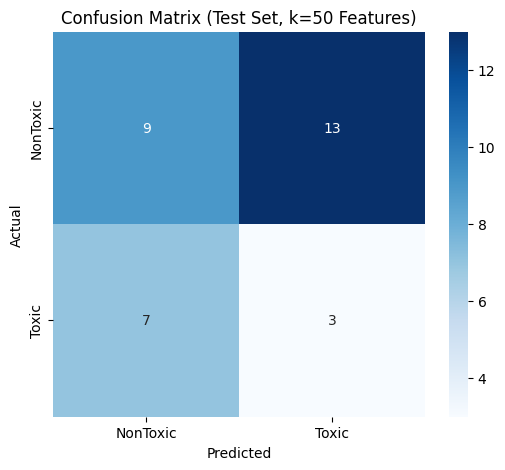

In [ ]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif

# Convert scaled training data back to a pandas DataFrame to easily get column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

# Perform univariate feature selection using f_classif (ANOVA F-value between label/feature for classification tasks)
# We will select the top k features based on their F-scores.
# Feature Selection with k=50
k = 50
selector = SelectKBest(score_func=f_classif, k=k)
X_train_selected_k50 = selector.fit_transform(X_train_scaled_df, y_train)
X_test_selected_k50 = selector.transform(X_test_scaled)

selected_feature_indices_k50 = selector.get_support(indices=True)
selected_feature_names_k50 = X_train_scaled_df.columns[selected_feature_indices_k50]
print(f"\n--- Feature Selection with k=50 ---")
print(f"Shape of X_train_selected (k=50): {X_train_selected_k50.shape}")
print(f"Shape of X_test_selected (k=50): {X_test_selected_k50.shape}")
print(f"Number of selected features (k=50): {len(selected_feature_names_k50)}")
print(f"First 20 selected feature names (k=50): {selected_feature_names_k50[:20].tolist()}")

# Train and Evaluate Logistic Regression with k=50 features
logreg_k50 = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')
cv_scores_k50 = cross_val_score(logreg_k50, X_train_selected_k50, y_train, cv=cv, scoring='accuracy')
print(f"\nCross-validation accuracy scores (k=50): {cv_scores_k50}")
print(f"Mean cross-validation accuracy (k=50): {cv_scores_k50.mean():.4f} (+/- {cv_scores_k50.std():.4f})")

logreg_k50.fit(X_train_selected_k50, y_train)
y_pred_k50 = logreg_k50.predict(X_test_selected_k50)

print("\n--- Test Set Evaluation (k=50 features) ---")
print(f"Test set accuracy (k=50): {accuracy_score(y_test, y_pred_k50):.4f}")
print("\nClassification Report (k=50):")
print(classification_report(y_test, y_pred_k50, target_names=label_encoder.classes_))

cm_k50 = confusion_matrix(y_test, y_pred_k50)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_k50, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set, k=50 Features)')
plt.show()


Cross-validation accuracy scores (with selected features): [0.61538462 0.57692308 0.6        0.76       0.44      ]
Mean cross-validation accuracy (with selected features): 0.5985 (+/- 0.1019)

--- Test Set Evaluation (with selected features) ---
Test set accuracy (with selected features): 0.4062

Classification Report (with selected features):
              precision    recall  f1-score   support

    NonToxic       0.60      0.41      0.49        22
       Toxic       0.24      0.40      0.30        10

    accuracy                           0.41        32
   macro avg       0.42      0.40      0.39        32
weighted avg       0.49      0.41      0.43        32



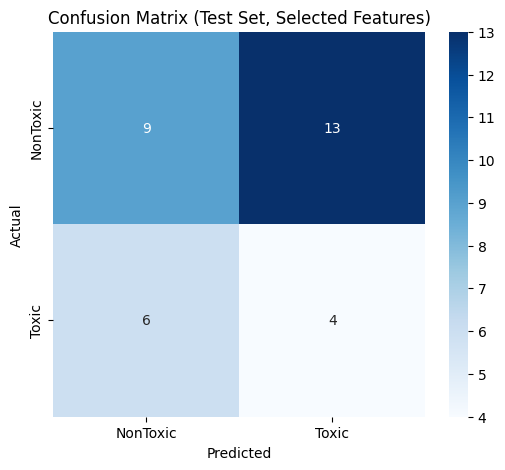

In [ ]:
# Initialize Logistic Regression model (same parameters as before)
logreg_selected = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')

# Define cross-validation strategy (same as before)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation on the training data with selected features
cv_scores_selected = cross_val_score(logreg_selected, X_train_selected, y_train, cv=cv, scoring='accuracy')
print(f"\nCross-validation accuracy scores (with selected features): {cv_scores_selected}")
print(f"Mean cross-validation accuracy (with selected features): {cv_scores_selected.mean():.4f} (+/- {cv_scores_selected.std():.4f})")

# Train the Logistic Regression model on the entire scaled training data with selected features
logreg_selected.fit(X_train_selected, y_train)

# Make predictions on the scaled test data with selected features
y_pred_selected = logreg_selected.predict(X_test_selected)

# Evaluate the model on the test data with selected features
print("\n--- Test Set Evaluation (with selected features) ---")
print(f"Test set accuracy (with selected features): {accuracy_score(y_test, y_pred_selected):.4f}")
print("\nClassification Report (with selected features):")
print(classification_report(y_test, y_pred_selected, target_names=label_encoder.classes_))

# Confusion Matrix (with selected features)
cm_selected = confusion_matrix(y_test, y_pred_selected)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_selected, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set, Selected Features)')
plt.show()


Cross-validation accuracy scores (LinearSVC, k=100): [0.46153846 0.65384615 0.64       0.68       0.56      ]
Mean cross-validation accuracy (LinearSVC, k=100): 0.5991 (+/- 0.0796)

--- Test Set Evaluation (LinearSVC, k=100 features) ---
Test set accuracy (LinearSVC, k=100): 0.3750

Classification Report (LinearSVC, k=100):
              precision    recall  f1-score   support

    NonToxic       0.56      0.41      0.47        22
       Toxic       0.19      0.30      0.23        10

    accuracy                           0.38        32
   macro avg       0.38      0.35      0.35        32
weighted avg       0.45      0.38      0.40        32



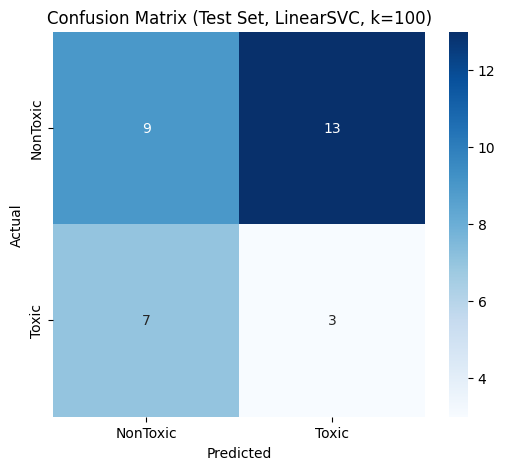

In [ ]:
from sklearn.svm import LinearSVC

# Initialize LinearSVC model
linear_svc = LinearSVC(random_state=42, class_weight='balanced', C=1.0)

# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores_svc = cross_val_score(linear_svc, X_train_selected, y_train, cv=cv, scoring='accuracy')
print(f"\nCross-validation accuracy scores (LinearSVC, k=100): {cv_scores_svc}")
print(f"Mean cross-validation accuracy (LinearSVC, k=100): {cv_scores_svc.mean():.4f} (+/- {cv_scores_svc.std():.4f})")

# Train on the entire training data
linear_svc.fit(X_train_selected, y_train)

# Make predictions on the test data
y_pred_svc = linear_svc.predict(X_test_selected)

# Evaluate the model
print("\n--- Test Set Evaluation (LinearSVC, k=100 features) ---")
print(f"Test set accuracy (LinearSVC, k=100): {accuracy_score(y_test, y_pred_svc):.4f}")
print("\nClassification Report (LinearSVC, k=100):")
print(classification_report(y_test, y_pred_svc, target_names=label_encoder.classes_))

# Confusion Matrix
cm_svc = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set, LinearSVC, k=100)')
plt.show()


Best parameters found by GridSearchCV: {'C': 0.01}
Best cross-validation accuracy from GridSearchCV: 0.6547692307692308

--- Test Set Evaluation (Tuned Logistic Regression, k=100 features) ---
Test set accuracy (tuned): 0.4062

Classification Report (tuned):
              precision    recall  f1-score   support

    NonToxic       0.62      0.36      0.46        22
       Toxic       0.26      0.50      0.34        10

    accuracy                           0.41        32
   macro avg       0.44      0.43      0.40        32
weighted avg       0.51      0.41      0.42        32



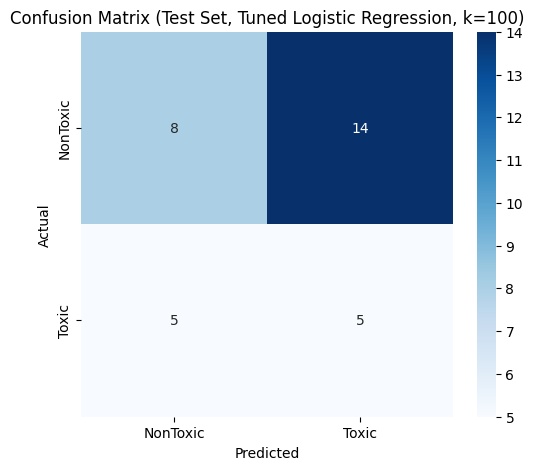

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for C
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Initialize Logistic Regression model (same as before)
logreg_tuned = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')

# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(logreg_tuned, param_grid, cv=cv, scoring='accuracy')
grid_search.fit(X_train_selected, y_train)

# Print the best parameters and the best cross-validation score
print("\nBest parameters found by GridSearchCV:", grid_search.best_params_)
print("Best cross-validation accuracy from GridSearchCV:", grid_search.best_score_)

# Get the best model from the grid search
best_logreg = grid_search.best_estimator_

# Make predictions on the test data using the best model
y_pred_tuned = best_logreg.predict(X_test_selected)

# Evaluate the best model on the test data
print("\n--- Test Set Evaluation (Tuned Logistic Regression, k=100 features) ---")
print(f"Test set accuracy (tuned): {accuracy_score(y_test, y_pred_tuned):.4f}")
print("\nClassification Report (tuned):")
print(classification_report(y_test, y_pred_tuned, target_names=label_encoder.classes_))

# Confusion Matrix (tuned)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set, Tuned Logistic Regression, k=100)')
plt.show()


Best parameters found by GridSearchCV (k-NN): {'n_neighbors': 11}
Best cross-validation accuracy from GridSearchCV (k-NN): 0.669846153846154

--- Test Set Evaluation (k-NN, k=...) ---
Test set accuracy (k-NN): 0.7188

Classification Report (k-NN):
              precision    recall  f1-score   support

    NonToxic       0.74      0.91      0.82        22
       Toxic       0.60      0.30      0.40        10

    accuracy                           0.72        32
   macro avg       0.67      0.60      0.61        32
weighted avg       0.70      0.72      0.69        32



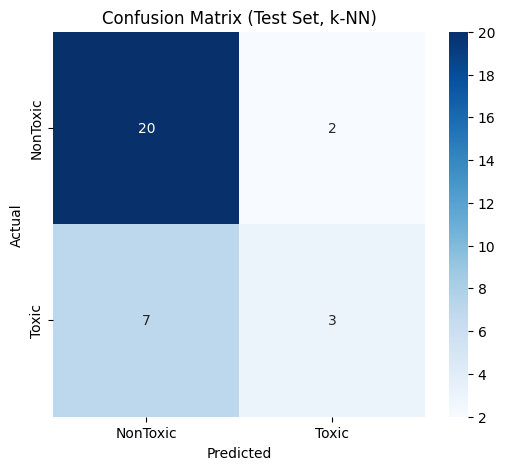

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Define the range of k values to try
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11]}

# Initialize k-NN classifier
knn = KNeighborsClassifier()

# Perform GridSearchCV for hyperparameter tuning (k)
grid_search_knn = GridSearchCV(knn, param_grid_knn, cv=cv, scoring='accuracy')
grid_search_knn.fit(X_train_selected, y_train)

# Print the best parameters and the best cross-validation score
print("\nBest parameters found by GridSearchCV (k-NN):", grid_search_knn.best_params_)
print("Best cross-validation accuracy from GridSearchCV (k-NN):", grid_search_knn.best_score_)

# Get the best k-NN model
best_knn = grid_search_knn.best_estimator_

# Make predictions on the test data
y_pred_knn = best_knn.predict(X_test_selected)

# Evaluate the best k-NN model
print("\n--- Test Set Evaluation (k-NN, k=...) ---")
print(f"Test set accuracy (k-NN): {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nClassification Report (k-NN):")
print(classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))

# Confusion Matrix (k-NN)
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set, k-NN)')
plt.show()


Best parameters found by GridSearchCV (k-NN Tuned): {'n_neighbors': 4, 'weights': 'uniform'}
Best cross-validation accuracy from GridSearchCV (k-NN Tuned): 0.684923076923077

--- Test Set Evaluation (Tuned k-NN) ---
Test set accuracy (tuned k-NN): 0.6875

Classification Report (tuned k-NN):
              precision    recall  f1-score   support

    NonToxic       0.71      0.91      0.80        22
       Toxic       0.50      0.20      0.29        10

    accuracy                           0.69        32
   macro avg       0.61      0.55      0.54        32
weighted avg       0.65      0.69      0.64        32



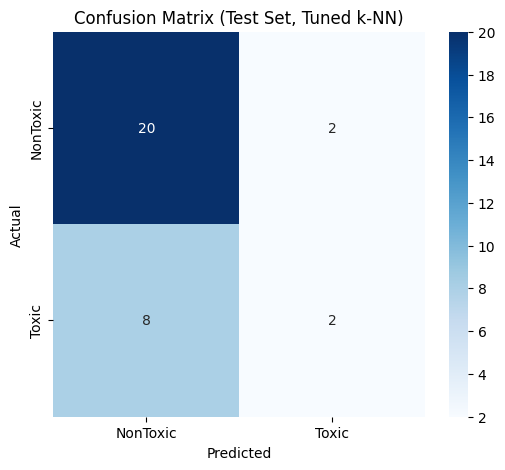

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Define a broader parameter grid for k-NN
param_grid_knn_tuned = {
    'n_neighbors': list(range(1, 21)),  #  k from 1 to 20
    'weights': ['uniform', 'distance']  # uniform and distance-based weighting
}

# Initialize k-NN classifier
knn_tuned = KNeighborsClassifier()

# Perform GridSearchCV for hyperparameter tuning
grid_search_knn_tuned = GridSearchCV(knn_tuned, param_grid_knn_tuned, cv=cv, scoring='accuracy')
grid_search_knn_tuned.fit(X_train_selected, y_train)

# Print the best parameters and the best cross-validation score
print("\nBest parameters found by GridSearchCV (k-NN Tuned):", grid_search_knn_tuned.best_params_)
print("Best cross-validation accuracy from GridSearchCV (k-NN Tuned):", grid_search_knn_tuned.best_score_)

# Get the best k-NN model
best_knn_tuned = grid_search_knn_tuned.best_estimator_

# Make predictions on the test data
y_pred_knn_tuned = best_knn_tuned.predict(X_test_selected)

# Evaluate the best k-NN model
print("\n--- Test Set Evaluation (Tuned k-NN) ---")
print(f"Test set accuracy (tuned k-NN): {accuracy_score(y_test, y_pred_knn_tuned):.4f}")
print("\nClassification Report (tuned k-NN):")
print(classification_report(y_test, y_pred_knn_tuned, target_names=label_encoder.classes_))

# Confusion Matrix (tuned k-NN)
cm_knn_tuned = confusion_matrix(y_test, y_pred_knn_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set, Tuned k-NN)')
plt.show()


Best parameters found by GridSearchCV (Decision Tree): {'class_weight': 'balanced', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation accuracy from GridSearchCV (Decision Tree): 0.5756923076923077

--- Test Set Evaluation (Tuned Decision Tree) ---
Test set accuracy (tuned Decision Tree): 0.5625

Classification Report (tuned Decision Tree):
              precision    recall  f1-score   support

    NonToxic       0.72      0.59      0.65        22
       Toxic       0.36      0.50      0.42        10

    accuracy                           0.56        32
   macro avg       0.54      0.55      0.53        32
weighted avg       0.61      0.56      0.58        32



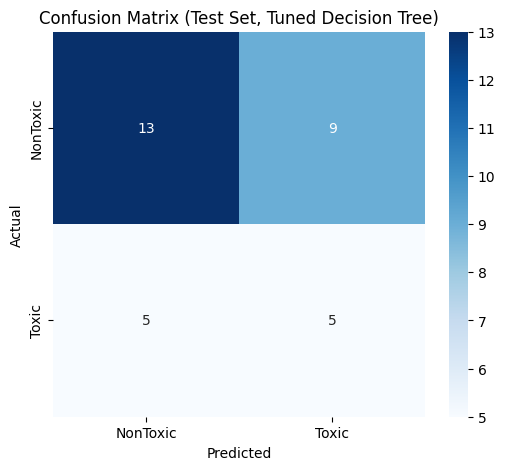

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define a parameter grid for a pruned Decision Tree
param_grid_dt = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'class_weight': ['balanced']
}

# Initialize Decision Tree classifier
dt = DecisionTreeClassifier(random_state=42)

# Perform GridSearchCV for hyperparameter tuning
grid_search_dt = GridSearchCV(dt, param_grid_dt, cv=cv, scoring='accuracy')
grid_search_dt.fit(X_train_selected, y_train)

# Print the best parameters and the best cross-validation score
print("\nBest parameters found by GridSearchCV (Decision Tree):", grid_search_dt.best_params_)
print("Best cross-validation accuracy from GridSearchCV (Decision Tree):", grid_search_dt.best_score_)

# Get the best Decision Tree model
best_dt = grid_search_dt.best_estimator_

# Make predictions on the test data
y_pred_dt = best_dt.predict(X_test_selected)

# Evaluate the best Decision Tree model
print("\n--- Test Set Evaluation (Tuned Decision Tree) ---")
print(f"Test set accuracy (tuned Decision Tree): {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nClassification Report (tuned Decision Tree):")
print(classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_))

# Confusion Matrix (tuned Decision Tree)
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set, Tuned Decision Tree)')
plt.show()


Best parameters found by GridSearchCV (k-NN Advanced): {'n_neighbors': 4, 'p': 2, 'weights': 'uniform'}
Best cross-validation accuracy from GridSearchCV (k-NN Advanced): 0.684923076923077

--- Test Set Evaluation (Tuned k-NN with Distance) ---
Test set accuracy (advanced tuned k-NN): 0.6875

Classification Report (advanced tuned k-NN):
              precision    recall  f1-score   support

    NonToxic       0.71      0.91      0.80        22
       Toxic       0.50      0.20      0.29        10

    accuracy                           0.69        32
   macro avg       0.61      0.55      0.54        32
weighted avg       0.65      0.69      0.64        32



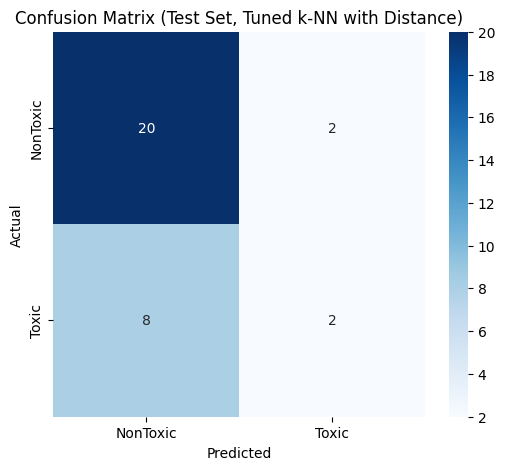

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Define a broader parameter grid for k-NN, including Minkowski distance
param_grid_knn_advanced = {
    'n_neighbors': list(range(1, 16)),  # k from 1 to 15
    'weights': ['uniform', 'distance'],
    'p': [1, 2, 3]  # 1: Manhattan, 2: Euclidean, 3: Minkowski with p=3
}

# Initialize k-NN classifier
knn_advanced = KNeighborsClassifier()

# Perform GridSearchCV for hyperparameter tuning
grid_search_knn_advanced = GridSearchCV(knn_advanced, param_grid_knn_advanced, cv=cv, scoring='accuracy')
grid_search_knn_advanced.fit(X_train_selected, y_train)

# Print the best parameters and the best cross-validation score
print("\nBest parameters found by GridSearchCV (k-NN Advanced):", grid_search_knn_advanced.best_params_)
print("Best cross-validation accuracy from GridSearchCV (k-NN Advanced):", grid_search_knn_advanced.best_score_)

# Get the best k-NN model
best_knn_advanced = grid_search_knn_advanced.best_estimator_

# Make predictions on the test data
y_pred_knn_advanced = best_knn_advanced.predict(X_test_selected)

# Evaluate the best k-NN model
print("\n--- Test Set Evaluation (Tuned k-NN with Distance) ---")
print(f"Test set accuracy (advanced tuned k-NN): {accuracy_score(y_test, y_pred_knn_advanced):.4f}")
print("\nClassification Report (advanced tuned k-NN):")
print(classification_report(y_test, y_pred_knn_advanced, target_names=label_encoder.classes_))

# Confusion Matrix (advanced tuned k-NN)
cm_knn_advanced = confusion_matrix(y_test, y_pred_knn_advanced)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn_advanced, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set, Tuned k-NN with Distance)')
plt.show()


--- Cross-Validation with SMOTE ---
Cross-validation accuracy scores (with SMOTE): [0.6666666666666666, 0.75, 0.45, 0.6, 0.65]
Mean cross-validation accuracy (with SMOTE): 0.6233

--- Test Set Evaluation (k-NN with SMOTE) ---
Test set accuracy (with SMOTE): 0.5625

Classification Report (with SMOTE):
              precision    recall  f1-score   support

    NonToxic       0.70      0.64      0.67        22
       Toxic       0.33      0.40      0.36        10

    accuracy                           0.56        32
   macro avg       0.52      0.52      0.52        32
weighted avg       0.59      0.56      0.57        32



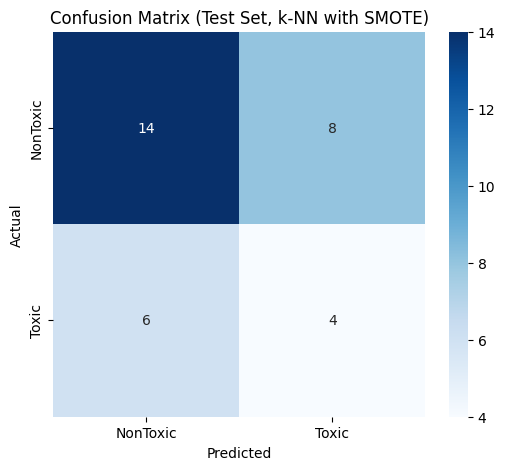

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Use the features selected by SelectKBest
X_train_selected_df = pd.DataFrame(X_train_selected)
X_test_selected_df = pd.DataFrame(X_test_selected)

# Split the selected training features and the corresponding training target
X_train_smote, X_val_smote, y_train_smote, y_val_smote = train_test_split(
    X_train_selected_df, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Initialize k-NN classifier with the best parameters found
best_knn_params = {'n_neighbors': 4, 'p': 2, 'weights': 'uniform'}
knn_smote = KNeighborsClassifier(**best_knn_params)

# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation with SMOTE applied to each training fold
accuracy_scores_smote = []
report_smote = []
cm_smote = []

for train_index, val_index in cv.split(X_train_smote, y_train_smote):
    X_train_fold, X_val_fold = X_train_smote.iloc[train_index], X_train_smote.iloc[val_index]
    y_train_fold, y_val_fold = y_train_smote[train_index], y_train_smote[val_index]

    # Apply SMOTE only to the training fold
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_fold, y_train_fold)

    # Train k-NN on the resampled training data
    knn_smote.fit(X_train_resampled, y_train_resampled)

    # Make predictions on the validation fold
    y_pred_val = knn_smote.predict(X_val_fold)

    # Evaluate and store metrics for each fold
    accuracy_scores_smote.append(accuracy_score(y_val_fold, y_pred_val))
    report_smote.append(classification_report(y_val_fold, y_pred_val, target_names=label_encoder.classes_, zero_division=0, output_dict=True))
    cm_smote.append(confusion_matrix(y_val_fold, y_pred_val))

print("\n--- Cross-Validation with SMOTE ---")
print(f"Cross-validation accuracy scores (with SMOTE): {accuracy_scores_smote}")
print(f"Mean cross-validation accuracy (with SMOTE): {sum(accuracy_scores_smote) / len(accuracy_scores_smote):.4f}")

# Apply SMOTE to the entire training set (selected features) and train the final model
X_train_resampled_final, y_train_resampled_final = smote.fit_resample(X_train_selected, y_train)
knn_smote.fit(X_train_resampled_final, y_train_resampled_final)

# Make predictions on the test data (selected features)
y_pred_test_smote = knn_smote.predict(X_test_selected)

# Evaluate on the test set
print("\n--- Test Set Evaluation (k-NN with SMOTE) ---")
print(f"Test set accuracy (with SMOTE): {accuracy_score(y_test, y_pred_test_smote):.4f}")
print("\nClassification Report (with SMOTE):")
print(classification_report(y_test, y_pred_test_smote, target_names=label_encoder.classes_))

# Confusion Matrix (with SMOTE)
cm_test_smote = confusion_matrix(y_test, y_pred_test_smote)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set, k-NN with SMOTE)')
plt.show()


--- Test Set Evaluation (Ensemble) ---
Test set accuracy (ensemble): 0.7188

Classification Report (ensemble):
              precision    recall  f1-score   support

    NonToxic       0.74      0.91      0.82        22
       Toxic       0.60      0.30      0.40        10

    accuracy                           0.72        32
   macro avg       0.67      0.60      0.61        32
weighted avg       0.70      0.72      0.69        32



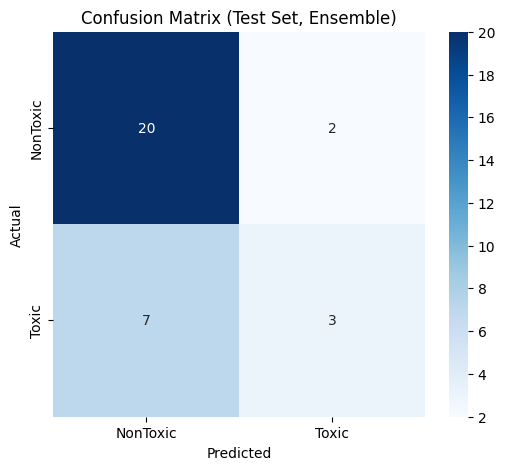

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the individual models with their best parameters
knn_best = KNeighborsClassifier(n_neighbors=11, p=2, weights='uniform')
logreg_best = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced', C=0.01)

# Create the voting classifier
voting_clf = VotingClassifier(estimators=[('knn', knn_best), ('lr', logreg_best)], voting='hard') # 'hard' voting

# Train the voting classifier on the entire training data (selected features)
voting_clf.fit(X_train_selected, y_train)

# Make predictions on the test data
y_pred_ensemble = voting_clf.predict(X_test_selected)

# Evaluate the ensemble
print("\n--- Test Set Evaluation (Ensemble) ---")
print(f"Test set accuracy (ensemble): {accuracy_score(y_test, y_pred_ensemble):.4f}")
print("\nClassification Report (ensemble):")
print(classification_report(y_test, y_pred_ensemble, target_names=label_encoder.classes_))

# Confusion Matrix (ensemble)
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set, Ensemble)')
plt.show()

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:16:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 


Best parameters found by GridSearchCV (XGBoost): {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best cross-validation accuracy from GridSearchCV (XGBoost): 0.6772307692307693

--- Test Set Evaluation (XGBoost) ---
Test set accuracy (XGBoost): 0.6875

Classification Report (XGBoost):
              precision    recall  f1-score   support

    NonToxic       0.69      1.00      0.81        22
       Toxic       0.00      0.00      0.00        10

    accuracy                           0.69        32
   macro avg       0.34      0.50      0.41        32
weighted avg       0.47      0.69      0.56        32



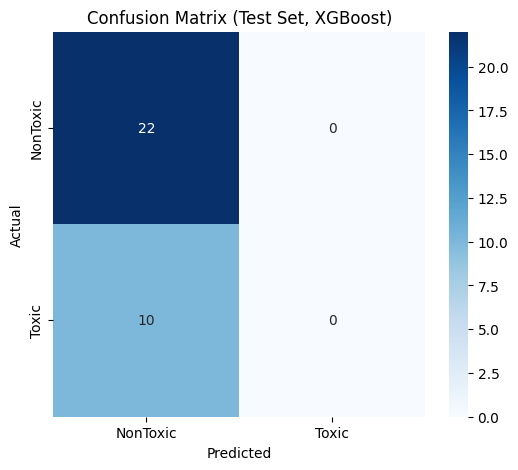

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize XGBoost classifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Define the hyperparameter grid to search
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Define the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform GridSearchCV for hyperparameter tuning
grid_search_xgb = GridSearchCV(xgb, param_grid_xgb, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search_xgb.fit(X_train_selected, y_train)

# Print the best parameters and the best cross-validation score
print("\nBest parameters found by GridSearchCV (XGBoost):", grid_search_xgb.best_params_)
print("Best cross-validation accuracy from GridSearchCV (XGBoost):", grid_search_xgb.best_score_)

# Get the best XGBoost model
best_xgb = grid_search_xgb.best_estimator_

# Make predictions on the test data
y_pred_xgb = best_xgb.predict(X_test_selected)

# Evaluate the best XGBoost model
print("\n--- Test Set Evaluation (XGBoost) ---")
print(f"Test set accuracy (XGBoost): {accuracy_score(y_test, y_pred_xgb):.4f}")
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb, target_names=label_encoder.classes_))

# Confusion Matrix (XGBoost)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set, XGBoost)')
plt.show()

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:18:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



--- Test Set Evaluation (XGBoost with Class Weight) ---
Test set accuracy (XGBoost with weight): 0.7500

Classification Report (XGBoost with weight):
              precision    recall  f1-score   support

    NonToxic       0.85      0.77      0.81        22
       Toxic       0.58      0.70      0.64        10

    accuracy                           0.75        32
   macro avg       0.72      0.74      0.72        32
weighted avg       0.77      0.75      0.76        32



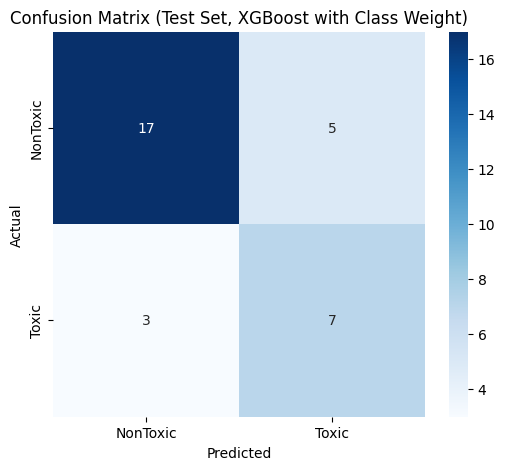

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize XGBoost classifier with class weight
xgb_weighted = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
                            scale_pos_weight=(86/41))

# Use the best parameters found earlier
best_params_xgb = {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
xgb_weighted.set_params(**best_params_xgb)

# Train the XGBoost model on the entire training data (selected features)
xgb_weighted.fit(X_train_selected, y_train)

# Make predictions on the test data
y_pred_xgb_weighted = xgb_weighted.predict(X_test_selected)

# Evaluate the weighted XGBoost model
print("\n--- Test Set Evaluation (XGBoost with Class Weight) ---")
print(f"Test set accuracy (XGBoost with weight): {accuracy_score(y_test, y_pred_xgb_weighted):.4f}")
print("\nClassification Report (XGBoost with weight):")
print(classification_report(y_test, y_pred_xgb_weighted, target_names=label_encoder.classes_))

# Confusion Matrix (XGBoost with weight)
cm_xgb_weighted = confusion_matrix(y_test, y_pred_xgb_weighted)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb_weighted, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set, XGBoost with Class Weight)')
plt.show()

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:22:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in 


Best parameters found by GridSearchCV (XGBoost Tuned): {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'scale_pos_weight': 1, 'subsample': 0.8}
Best cross-validation accuracy from GridSearchCV (XGBoost Tuned): 0.6772307692307693

--- Test Set Evaluation (Tuned XGBoost) ---
Test set accuracy (tuned XGBoost): 0.6875

Classification Report (tuned XGBoost):
              precision    recall  f1-score   support

    NonToxic       0.69      1.00      0.81        22
       Toxic       0.00      0.00      0.00        10

    accuracy                           0.69        32
   macro avg       0.34      0.50      0.41        32
weighted avg       0.47      0.69      0.56        32



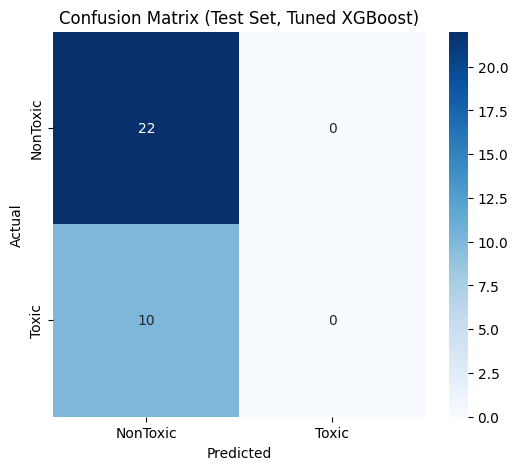

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize XGBoost classifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Define the hyperparameter grid to search, including scale_pos_weight
param_grid_xgb_tuned = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, 2, (86/41)]
}

# Define the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform GridSearchCV for hyperparameter tuning
grid_search_xgb_tuned = GridSearchCV(xgb, param_grid_xgb_tuned, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search_xgb_tuned.fit(X_train_selected, y_train)

# Print the best parameters and the best cross-validation score
print("\nBest parameters found by GridSearchCV (XGBoost Tuned):", grid_search_xgb_tuned.best_params_)
print("Best cross-validation accuracy from GridSearchCV (XGBoost Tuned):", grid_search_xgb_tuned.best_score_)

# Get the best XGBoost model
best_xgb_tuned = grid_search_xgb_tuned.best_estimator_

# Make predictions on the test data
y_pred_xgb_tuned = best_xgb_tuned.predict(X_test_selected)

# Evaluate the best XGBoost model
print("\n--- Test Set Evaluation (Tuned XGBoost) ---")
print(f"Test set accuracy (tuned XGBoost): {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")
print("\nClassification Report (tuned XGBoost):")
print(classification_report(y_test, y_pred_xgb_tuned, target_names=label_encoder.classes_))

# Confusion Matrix (tuned XGBoost)
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set, Tuned XGBoost)')
plt.show()

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:28:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Best parameters found by GridSearchCV (scale_pos_weight): {'scale_pos_weight': 3}
Best cross-validation F1 score (Toxic): 0.5243456415870209

--- Test Set Evaluation (XGBoost with Tuned Class Weight) ---
Test set accuracy (tuned weight XGBoost): 0.5312

Classification Report (tuned weight XGBoost):
              precision    recall  f1-score   support

    NonToxic       0.89      0.36      0.52        22
       Toxic       0.39      0.90      0.55        10

    accuracy                           0.53        32
   macro avg       0.64      0.63      0.53        32
weighted avg       0.73      0.53      0.53        32



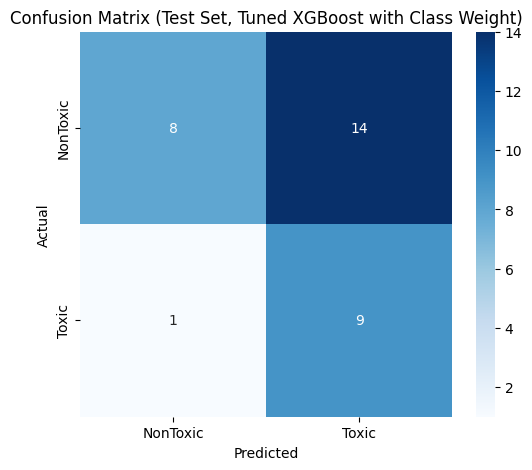

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, make_scorer
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize XGBoost classifier
xgb_focused = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,
                            colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=50, subsample=0.8)

# Define the hyperparameter grid for scale_pos_weight
param_grid_spw = {
    'scale_pos_weight': [1, 2, 3, 4, 5, (86/41)]
}

# Define the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define a scorer for the F1 score of the positive class ('Toxic', which is class 1)
f1_toxic = make_scorer(f1_score, pos_label=1)

# Perform GridSearchCV focusing on the F1 score of the positive class
grid_search_spw = GridSearchCV(xgb_focused, param_grid_spw, cv=cv, scoring=f1_toxic, n_jobs=-1)
grid_search_spw.fit(X_train_selected, y_train)

# Print the best parameters and the best cross-validation score
print("\nBest parameters found by GridSearchCV (scale_pos_weight):", grid_search_spw.best_params_)
print("Best cross-validation F1 score (Toxic):", grid_search_spw.best_score_)

# Get the best XGBoost model
best_xgb_spw = grid_search_spw.best_estimator_

# Make predictions on the test data
y_pred_xgb_spw = best_xgb_spw.predict(X_test_selected)

# Evaluate the best XGBoost model
print("\n--- Test Set Evaluation (XGBoost with Tuned Class Weight) ---")
print(f"Test set accuracy (tuned weight XGBoost): {accuracy_score(y_test, y_pred_xgb_spw):.4f}")
print("\nClassification Report (tuned weight XGBoost):")
print(classification_report(y_test, y_pred_xgb_spw, target_names=label_encoder.classes_))

# Confusion Matrix (tuned weight XGBoost)
cm_xgb_spw = confusion_matrix(y_test, y_pred_xgb_spw)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb_spw, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set, Tuned XGBoost with Class Weight)')
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# Get predicted probabilities from the XGBoost model with tuned class weight
y_pred_proba_xgb_tuned = best_xgb_spw.predict_proba(X_test_selected)[:, 1] # Probability of being 'Toxic' (class 1)

# Try different thresholds
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba_xgb_tuned > threshold).astype(int)

    print(f"\n--- Evaluation with Threshold = {threshold:.1f} ---")
    print(f"Test set accuracy: {accuracy_score(y_test, y_pred_threshold):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_threshold, target_names=label_encoder.classes_))
    cm_threshold = confusion_matrix(y_test, y_pred_threshold)
    print("\nConfusion Matrix:")
    print(cm_threshold)


--- Evaluation with Threshold = 0.1 ---
Test set accuracy: 0.3125

Classification Report:
              precision    recall  f1-score   support

    NonToxic       0.00      0.00      0.00        22
       Toxic       0.31      1.00      0.48        10

    accuracy                           0.31        32
   macro avg       0.16      0.50      0.24        32
weighted avg       0.10      0.31      0.15        32


Confusion Matrix:
[[ 0 22]
 [ 0 10]]

--- Evaluation with Threshold = 0.2 ---
Test set accuracy: 0.3125

Classification Report:
              precision    recall  f1-score   support

    NonToxic       0.00      0.00      0.00        22
       Toxic       0.31      1.00      0.48        10

    accuracy                           0.31        32
   macro avg       0.16      0.50      0.24        32
weighted avg       0.10      0.31      0.15        32


Confusion Matrix:
[[ 0 22]
 [ 0 10]]

--- Evaluation with Threshold = 0.3 ---
Test set accuracy: 0.3125

Classification Repor

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
import pickle

# Save the best XGBoost model
filename = 'best_xgboost_model.pkl'
pickle.dump(best_xgb_spw, open(filename, 'wb'))

print(f"\nBest XGBoost model saved as {filename}")


Best XGBoost model saved as best_xgboost_model.pkl


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Cross-Validation Results (Neural Network) ---
Cross-validation accuracy scores: [0.7307692170143127, 0.692307710647583, 0.800000011920929, 0.8799999952316284, 0.6800000071525574]
Mean cross-validation accuracy: 0.7566


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step

--- Test Set Evaluation (Neural Network) ---
Test set accuracy (Neural Network): 0.6875

Classification Report (Neural Network):
              precision    recall  f1-score   support

    NonToxic       0.71      0.91      0.80        22
       Toxic       0.50      0.20      0.29        10

    accuracy                           0.69        32
   macro avg       0.61      0.55      0.54        32
weighted avg       0.65      0.69      0.64        32



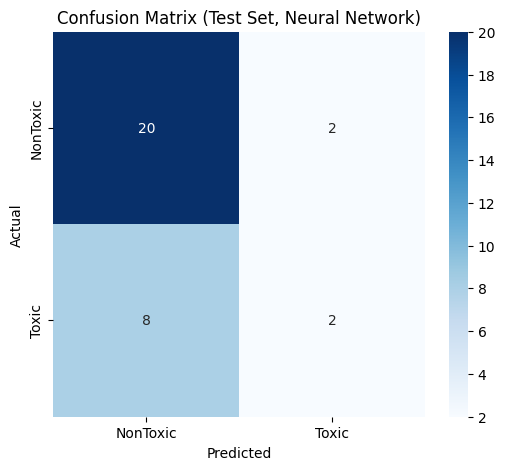

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Scale the features (important for neural networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

# Define the neural network model
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=keras.regularizers.l2(0.01)),
    layers.Dropout(0.5),
    layers.Dense(8, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') # Binary classification output
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Define cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accuracy_scores_nn = []
history_nn = []

# Train and evaluate using cross-validation
for train_index, val_index in cv.split(X_train_scaled, y_train):
    X_train_fold, X_val_fold = X_train_scaled[train_index], X_train_scaled[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    history = model.fit(X_train_fold, y_train_fold, epochs=50, batch_size=16,
                        validation_data=(X_val_fold, y_val_fold), verbose=0)
    accuracy_scores_nn.append(model.evaluate(X_val_fold, y_val_fold, verbose=0)[1])
    history_nn.append(history)

print("\n--- Cross-Validation Results (Neural Network) ---")
print(f"Cross-validation accuracy scores: {accuracy_scores_nn}")
print(f"Mean cross-validation accuracy: {np.mean(accuracy_scores_nn):.4f}")

# Train the final model on the entire scaled training data
final_model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],), kernel_regularizer=keras.regularizers.l2(0.01)),
    layers.Dropout(0.5),
    layers.Dense(8, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

final_model.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

final_model.fit(X_train_scaled, y_train, epochs=100, batch_size=16, verbose=0)

# Make predictions on the scaled test data
y_pred_proba_nn = final_model.predict(X_test_scaled)
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)

# Evaluate the final model
print("\n--- Test Set Evaluation (Neural Network) ---")
print(f"Test set accuracy (Neural Network): {accuracy_score(y_test, y_pred_nn):.4f}")
print("\nClassification Report (Neural Network):")
print(classification_report(y_test, y_pred_nn, target_names=label_encoder.classes_))

# Confusion Matrix (Neural Network)
cm_nn = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Test Set, Neural Network)')
plt.show()